In [1]:
# Cell 1
# Import necessary libraries for data handling and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree

# Load the dataset
# Note: Bank marketing dataset usually uses ';' as a separator. 
# If your data is comma-separated, remove the sep=';' part.
df = pd.read_csv('bank.csv', sep=';')

# Display the first 5 rows to understand the features
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [2]:
# Cell 2
# Check if the target column is named 'y' or 'deposit'
target_col = 'y' if 'y' in df.columns else 'deposit'

# Convert the target variable to binary (yes=1, no=0)
df[target_col] = df[target_col].map({'yes': 1, 'no': 0})

# Separate features (X) and target (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# Convert all text/categorical columns in X into dummy variables (0s and 1s)
X = pd.get_dummies(X, drop_first=True)

print("Data Preprocessing Completed. Shape of X:", X.shape)

Data Preprocessing Completed. Shape of X: (4521, 42)


In [3]:
# Cell 3
# Split the dataset into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier
# max_depth limits how deep the tree grows to prevent overfitting
clf = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train (fit) the model using the training data
clf.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


Model Accuracy: 90.61%

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       807
           1       0.61      0.36      0.45        98

    accuracy                           0.91       905
   macro avg       0.77      0.66      0.70       905
weighted avg       0.89      0.91      0.89       905



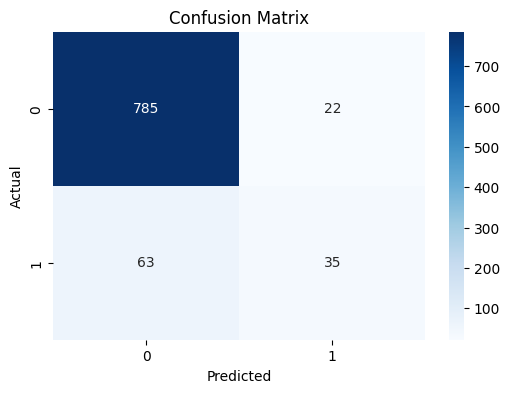

In [4]:
# Cell 4
# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Display the classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot and save the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Save the matrix graph
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

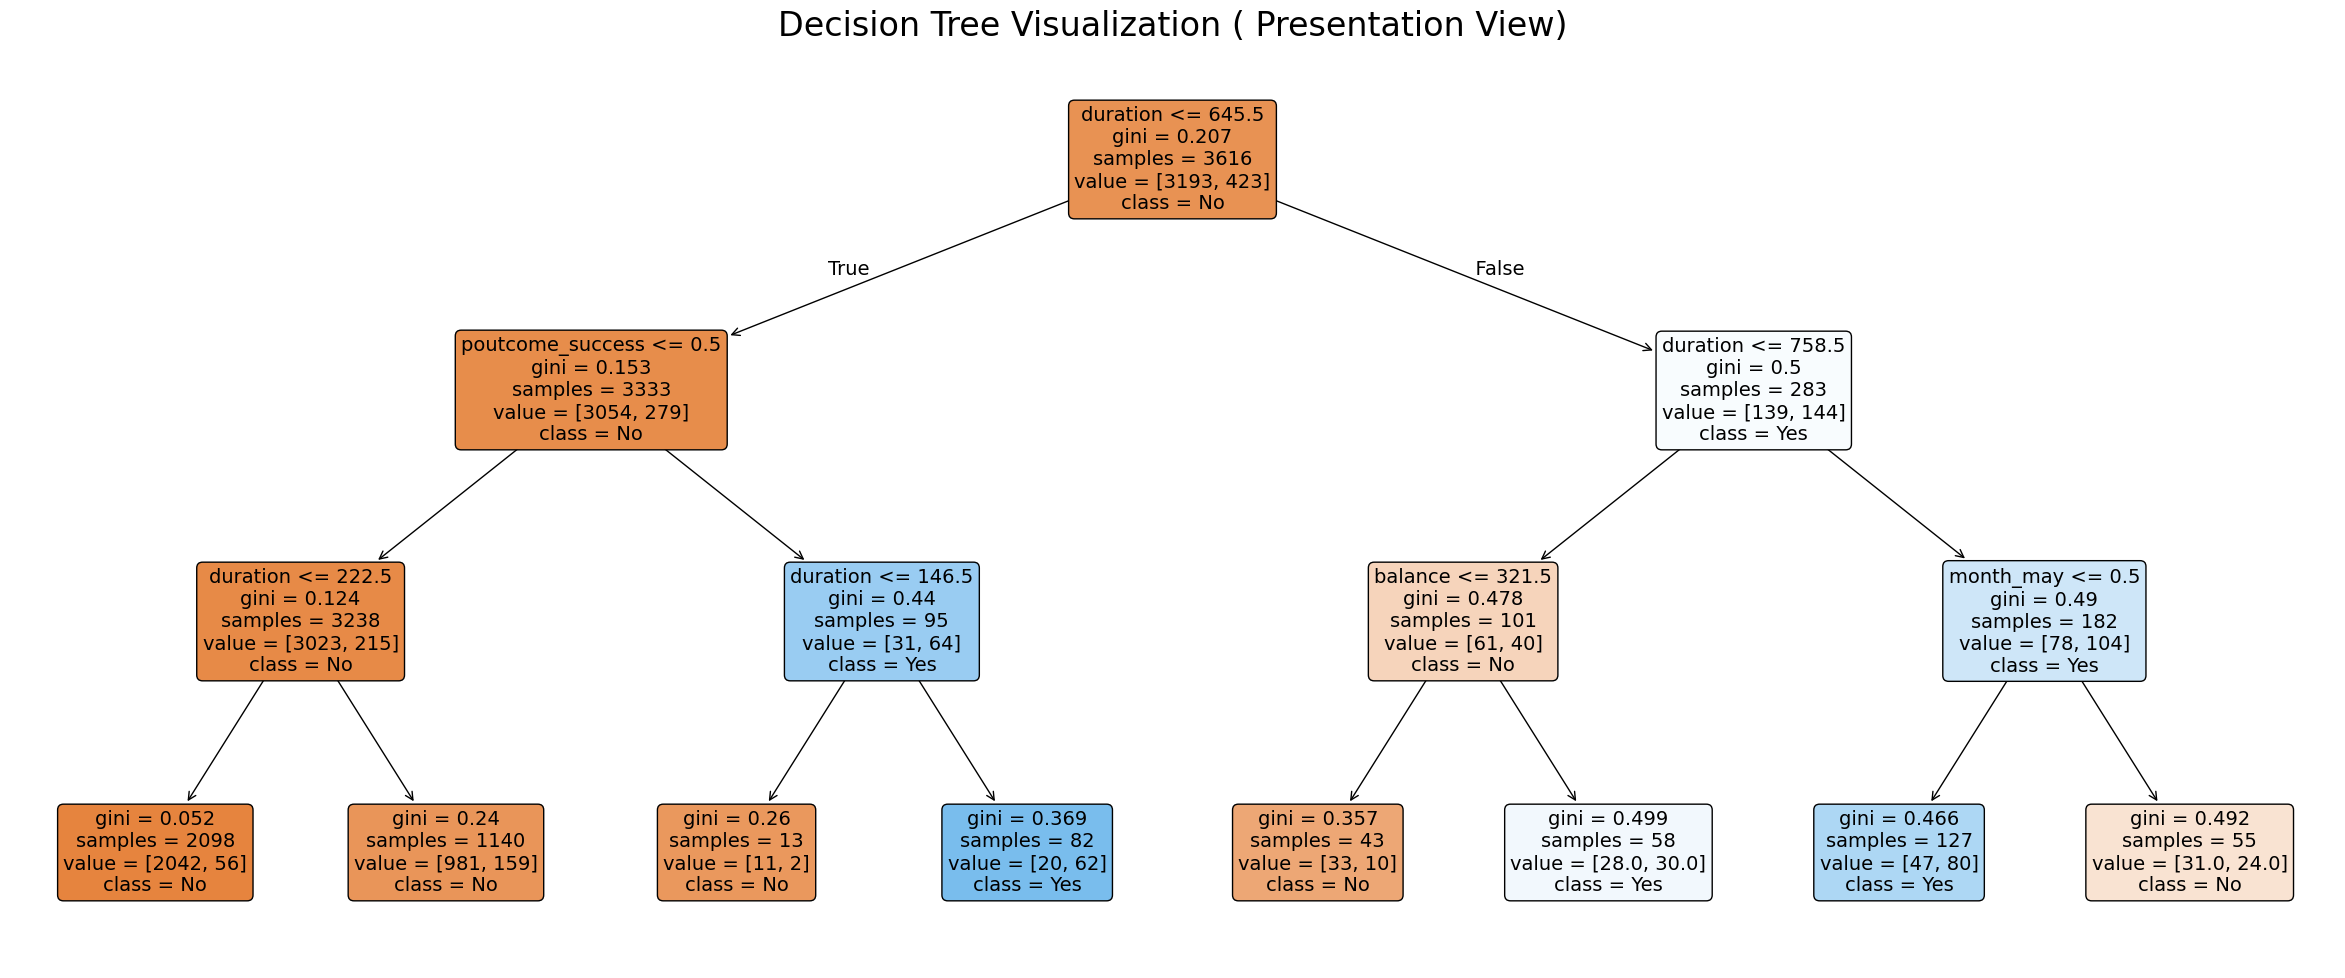

In [8]:
# Cell 5: Create a streamlined, clearer visualization for presentation

# The main evaluation (accuracy) still relies on the deeper model trained earlier.

# 1. Initialize and train a simpler classifier with max_depth=3 

clf_visual = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_visual.fit(X_train, y_train)

# 2. Setup the figure size for a wide and clear layout
# (30, 12) provides ample horizontal space for branches
plt.figure(figsize=(30, 12))

# 3. Plot the streamlined decision tree

tree.plot_tree(clf_visual, 
               feature_names=X.columns, 
               class_names=['No', 'Yes'], 
               filled=True, 
               rounded=True, 
               fontsize=14) 

# 4. Add a clear title to the plot
plt.title('Decision Tree Visualization ( Presentation View)', fontsize=24)

# 5. Save the clarified visualization as a high-resolution image to the folder

plt.savefig('decision_tree.png', dpi=300, bbox_inches='tight')

# 6. Display the final plot
plt.show()